# Logistic Regression
## class_weights

In [11]:
# ---- class_weight comparison: does weighting the minority class reduce false negatives? ----
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report, recall_score
import pandas as pd

In [12]:
# Rebuild X, y (Amyloid + Total tau, MCI only) — same as cell 45
df = pd.read_csv("data/plasma_lipidomics.csv")

In [13]:
mci = df[df['Diagnostic'] == 'Mild Cognitive Impairment'].copy()
amyloid_median = mci['CSF Amyloid (pg/mL)'].median()
mci['CSF Amyloid (pg/mL)'] = mci['CSF Amyloid (pg/mL)'].fillna(amyloid_median)
tau_median = mci['CSF Total tau (pg/mL)'].median()
mci['CSF Total tau (pg/mL)'] = mci['CSF Total tau (pg/mL)'].fillna(tau_median)

mci['target'] = (mci["Progression to Alzheimer's Disease"] == 'Yes').astype(int)
y = mci['target']
X = mci[['CSF Amyloid (pg/mL)', 'CSF Total tau (pg/mL)']]

print("Class balance (0=No progression, 1=Progressed):")
print(y.value_counts(), "\n")

Class balance (0=No progression, 1=Progressed):
target
1    47
0    42
Name: count, dtype: int64 



In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

weight_options = {
    'None (baseline)':           None,
    "'balanced'":                'balanced',
    "custom {0:1, 1:2}":         {0: 1, 1: 2},
    "custom {0:1, 1:3}":         {0: 1, 1: 3},
    "custom {0:1, 1:4}":         {0: 1, 1: 4},
    "custom {0:1, 1:5}":         {0: 1, 1: 5},
    "custom {0:1, 1:6}":         {0: 1, 1: 6},
}

for label, cw in weight_options.items():
    model = Pipeline([
        ('sc', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, class_weight=cw))
    ])
    y_pred = cross_val_predict(model, X, y, cv=cv, method='predict')

    print(f"--- class_weight = {label} ---")
    cm = confusion_matrix(y, y_pred, labels=[0, 1])
    print(pd.DataFrame(cm, index=['Actual: No', 'Actual: Yes'], columns=['Pred: No', 'Pred: Yes']))
    print(classification_report(y, y_pred, target_names=['No progression', 'Progressed'], digits=3))
    print('Recall (Progressed):', recall_score(y, y_pred))
    print("\n\n-------------------------------------\n")

--- class_weight = None (baseline) ---
             Pred: No  Pred: Yes
Actual: No         29         13
Actual: Yes        11         36
                precision    recall  f1-score   support

No progression      0.725     0.690     0.707        42
    Progressed      0.735     0.766     0.750        47

      accuracy                          0.730        89
     macro avg      0.730     0.728     0.729        89
  weighted avg      0.730     0.730     0.730        89

Recall (Progressed): 0.7659574468085106


-------------------------------------

--- class_weight = 'balanced' ---
             Pred: No  Pred: Yes
Actual: No         30         12
Actual: Yes        11         36
                precision    recall  f1-score   support

No progression      0.732     0.714     0.723        42
    Progressed      0.750     0.766     0.758        47

      accuracy                          0.742        89
     macro avg      0.741     0.740     0.740        89
  weighted avg      0.741  

In [15]:
# ---- class_weight sweep: confusion matrix + ROC-AUC + PR-AUC side by side ----
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (confusion_matrix, classification_report,
                              recall_score, precision_score,
                              roc_auc_score, average_precision_score)


weight_options = {
    'None (baseline)':     None,
    "'balanced'":           'balanced',
    "custom {0:1, 1:2}":    {0: 1, 1: 2},
    "custom {0:1, 1:3}":    {0: 1, 1: 3},
    "custom {0:1, 1:6}":    {0: 1, 1: 6},
}

summary_rows = []

for label, cw in weight_options.items():
    model = Pipeline([
        ('sc', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, class_weight=cw))
    ])
    y_pred  = cross_val_predict(model, X, y, cv=cv, method='predict')
    y_proba = cross_val_predict(model, X, y, cv=cv, method='predict_proba')[:, 1]

    cm = confusion_matrix(y, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    print(f"--- class_weight = {label} ---")
    print(pd.DataFrame(cm, index=['Actual: No', 'Actual: Yes'], columns=['Pred: No', 'Pred: Yes']))
    print(classification_report(y, y_pred, target_names=['No progression', 'Progressed'], digits=3))

    roc_auc = roc_auc_score(y, y_proba)
    pr_auc  = average_precision_score(y, y_proba)   # PR-AUC, positive class = 1
    print(f"ROC-AUC: {roc_auc:.3f}   PR-AUC: {pr_auc:.3f}\n")

    summary_rows.append({
        'class_weight':   label,
        'FN': fn, 'FP': fp,
        'Recall (Progressed)':    recall_score(y, y_pred),
        'Precision (Progressed)': precision_score(y, y_pred),
        'ROC-AUC': round(roc_auc, 3),
        'PR-AUC':  round(pr_auc, 3),
    })

# ---- Summary table across all weight settings ----
summary_df = pd.DataFrame(summary_rows)
print("=== Summary across class_weight sweep ===")
print(summary_df.to_string(index=False))

--- class_weight = None (baseline) ---
             Pred: No  Pred: Yes
Actual: No         29         13
Actual: Yes        11         36
                precision    recall  f1-score   support

No progression      0.725     0.690     0.707        42
    Progressed      0.735     0.766     0.750        47

      accuracy                          0.730        89
     macro avg      0.730     0.728     0.729        89
  weighted avg      0.730     0.730     0.730        89

ROC-AUC: 0.801   PR-AUC: 0.828

--- class_weight = 'balanced' ---
             Pred: No  Pred: Yes
Actual: No         30         12
Actual: Yes        11         36
                precision    recall  f1-score   support

No progression      0.732     0.714     0.723        42
    Progressed      0.750     0.766     0.758        47

      accuracy                          0.742        89
     macro avg      0.741     0.740     0.740        89
  weighted avg      0.741     0.742     0.741        89

ROC-AUC: 0.801   PR

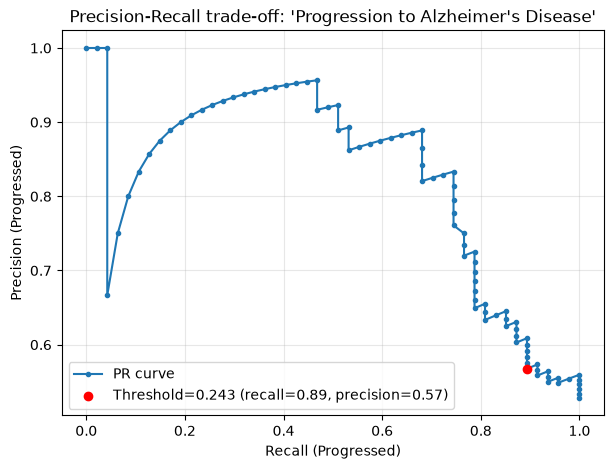

Precision / Recall at various thresholds:

 Target recall  Actual recall  Precision  Threshold
          0.70          0.702      0.825      0.592
          0.80          0.809      0.633      0.417
          0.85          0.851      0.625      0.330
          0.90          0.894      0.568      0.243
          0.95          0.957      0.549      0.161
          1.00          1.000      0.528      0.030

--- Confusion matrix at threshold = 0.030 ---
             Pred: No  Pred: Yes
Actual: No          0         42
Actual: Yes         0         47
                precision    recall  f1-score   support

No progression      0.000     0.000     0.000        42
    Progressed      0.528     1.000     0.691        47

      accuracy                          0.528        89
     macro avg      0.264     0.500     0.346        89
  weighted avg      0.279     0.528     0.365        89



C:\Users\david\miniconda3\envs\ucb\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\david\miniconda3\envs\ucb\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\david\miniconda3\envs\ucb\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

In [16]:
# ---- Precision-Recall curve: pick the exact threshold for your target recall ----
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_recall_curve, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Rebuild X, y (Amyloid + Total tau, MCI only) — same as cell 45
df = pd.read_csv("data/plasma_lipidomics.csv")
mci = df[df['Diagnostic'] == 'Mild Cognitive Impairment'].copy()
amyloid_median = mci['CSF Amyloid (pg/mL)'].median()
mci['CSF Amyloid (pg/mL)'] = mci['CSF Amyloid (pg/mL)'].fillna(amyloid_median)
tau_median = mci['CSF Total tau (pg/mL)'].median()
mci['CSF Total tau (pg/mL)'] = mci['CSF Total tau (pg/mL)'].fillna(tau_median)
mci['target'] = (mci["Progression to Alzheimer's Disease"] == 'Yes').astype(int)
y = mci['target']
X = mci[['CSF Amyloid (pg/mL)', 'CSF Total tau (pg/mL)']]

# Use the UNWEIGHTED model — class_weight only shifts the threshold, and we're
# about to pick the threshold explicitly, so no need to fight it with weights too
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model = Pipeline([('sc', StandardScaler()), ('clf', LogisticRegression(max_iter=1000))])
y_proba = cross_val_predict(model, X, y, cv=cv, method='predict_proba')[:, 1]

precision, recall, thresholds = precision_recall_curve(y, y_proba)

# ---- Plot ----
plt.figure(figsize=(7, 5))
plt.plot(recall, precision, marker='.', label='PR curve')
plt.xlabel('Recall (Progressed)')
plt.ylabel('Precision (Progressed)')
plt.title("Precision-Recall trade-off: 'Progression to Alzheimer's Disease'")
plt.grid(alpha=0.3)

# Mark a target recall, e.g. 90%
target_recall = 0.90
idx = np.argmin(np.abs(recall[:-1] - target_recall))  # last element has no threshold
plt.scatter(recall[idx], precision[idx], color='red', zorder=5,
            label=f'Threshold={thresholds[idx]:.3f} (recall={recall[idx]:.2f}, precision={precision[idx]:.2f})')
plt.legend()
plt.savefig("precision_recall_curve", dpi=300, bbox_inches="tight")
plt.show()

# ---- Table of thresholds around common recall targets ----
print("Precision / Recall at various thresholds:\n")
table_rows = []
for target in [0.70, 0.80, 0.85, 0.90, 0.95, 1.00]:
    idx = np.argmin(np.abs(recall[:-1] - target))
    table_rows.append({
        'Target recall': target,
        'Actual recall': round(recall[idx], 3),
        'Precision':     round(precision[idx], 3),
        'Threshold':     round(thresholds[idx], 3),
    })
print(pd.DataFrame(table_rows).to_string(index=False))

# ---- Apply a chosen threshold and show the resulting confusion matrix ----
chosen_threshold = thresholds[idx]  # or set manually, e.g. chosen_threshold = 0.35
y_pred_at_threshold = (y_proba >= chosen_threshold).astype(int)

print(f"\n--- Confusion matrix at threshold = {chosen_threshold:.3f} ---")
cm = confusion_matrix(y, y_pred_at_threshold, labels=[0, 1])
print(pd.DataFrame(cm, index=['Actual: No', 'Actual: Yes'], columns=['Pred: No', 'Pred: Yes']))
print(classification_report(y, y_pred_at_threshold, target_names=['No progression', 'Progressed'], digits=3))

 weight  FN  FP
    1.0  11  13
    2.0   6  23
    2.5   5  28
    3.0   5  31
    3.5   4  34
    4.0   3  36
    4.5   3  37
    5.0   1  37
    5.5   1  38
    6.0   0  38

Exchange rate (FP added per FN avoided), between each consecutive weight:
 weight  FN  FP  FN_drop  FP_rise  exchange_rate
    1.0  11  13      NaN      NaN            NaN
    2.0   6  23      5.0     10.0            2.0
    2.5   5  28      1.0      5.0            5.0
    3.0   5  31     -0.0      3.0           -inf
    3.5   4  34      1.0      3.0            3.0
    4.0   3  36      1.0      2.0            2.0
    4.5   3  37     -0.0      1.0           -inf
    5.0   1  37      2.0      0.0            0.0
    5.5   1  38     -0.0      1.0           -inf
    6.0   0  38      1.0      0.0            0.0


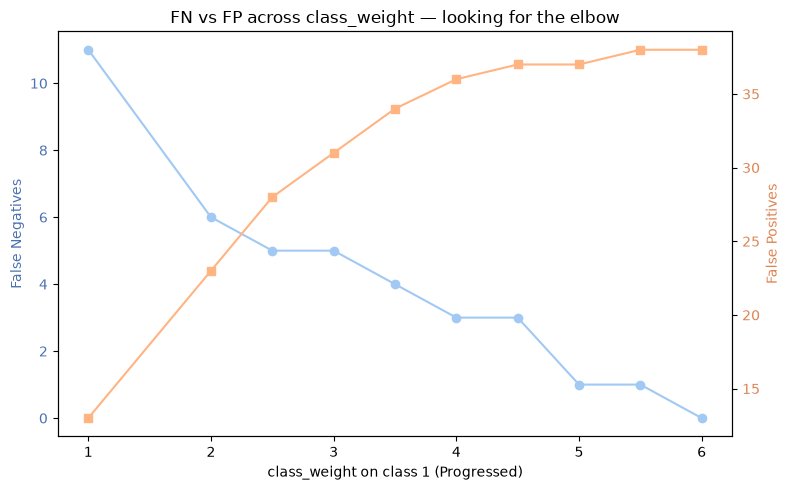

In [18]:
# ---- Finer class_weight sweep between 1:3 and 1:6, looking for the FN/FP elbow ----
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Rebuild X, y (Amyloid + Total tau, MCI only) — same as cell 45
df = pd.read_csv("data/plasma_lipidomics.csv")
mci = df[df['Diagnostic'] == 'Mild Cognitive Impairment'].copy()
amyloid_median = mci['CSF Amyloid (pg/mL)'].median()
mci['CSF Amyloid (pg/mL)'] = mci['CSF Amyloid (pg/mL)'].fillna(amyloid_median)
tau_median = mci['CSF Total tau (pg/mL)'].median()
mci['CSF Total tau (pg/mL)'] = mci['CSF Total tau (pg/mL)'].fillna(tau_median)
mci['target'] = (mci["Progression to Alzheimer's Disease"] == 'Yes').astype(int)
y = mci['target']
X = mci[['CSF Amyloid (pg/mL)', 'CSF Total tau (pg/mL)']]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Fine-grained weights on the minority (class 1) side, between 3 and 6
weight_values = [1, 2, 2.5, 3, 3.5, 4, 4.5, 5, 5.5, 6]

rows = []
for w in weight_values:
    model = Pipeline([
        ('sc', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, class_weight={0: 1, 1: w}))
    ])
    y_pred = cross_val_predict(model, X, y, cv=cv, method='predict')
    cm = confusion_matrix(y, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    rows.append({'weight': w, 'FN': fn, 'FP': fp})

sweep_df = pd.DataFrame(rows)
print(sweep_df.to_string(index=False))

# ---- Elbow: where does FP start rising faster than FN falls? ----
sweep_df['FN_drop']  = -sweep_df['FN'].diff()   # positive = FN improved
sweep_df['FP_rise']  = sweep_df['FP'].diff()    # positive = FP got worse
sweep_df['exchange_rate'] = sweep_df['FP_rise'] / sweep_df['FN_drop']  # FP paid per FN avoided
print("\nExchange rate (FP added per FN avoided), between each consecutive weight:")
print(sweep_df[['weight', 'FN', 'FP', 'FN_drop', 'FP_rise', 'exchange_rate']].to_string(index=False))

# ---- Plot both curves together ----
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(sweep_df['weight'], sweep_df['FN'], marker='o', color='#a1c9f4', label='False Negatives')
ax1.set_xlabel('class_weight on class 1 (Progressed)')
ax1.set_ylabel('False Negatives', color='#4c72b0')
ax1.tick_params(axis='y', labelcolor='#4c72b0')

ax2 = ax1.twinx()
ax2.plot(sweep_df['weight'], sweep_df['FP'], marker='s', color='#ffb482', label='False Positives')
ax2.set_ylabel('False Positives', color='#dd8452')
ax2.tick_params(axis='y', labelcolor='#dd8452')

plt.title('FN vs FP across class_weight — looking for the elbow')
fig.tight_layout()
plt.savefig("images/fn_fp_elbow", dpi=300, bbox_inches="tight")
plt.show()